# Credit Card Fraud Detection

A binary classifier that flags fraudulent transactions from the Kaggle "Credit Card Fraud
Detection" dataset (anonymized, PCA-transformed real transactions, ~284,807 rows, ~0.17% fraud).

Pipeline: EDA -> dedup/leakage fix -> baseline -> model comparison -> threshold tuned on
validation -> test-set evaluation (touched once) -> error analysis -> explainability ->
confidence-based routing.


## 1. Load data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

df_raw = pd.read_csv("data/creditcard.csv")
print("Raw shape:", df_raw.shape)
df_raw.head()


Raw shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### What the columns mean

- `Time`: seconds elapsed between this transaction and the first transaction in the dataset.
- `V1`...`V28`: PCA-transformed features (original features are confidential, so Kaggle released
  anonymized principal components instead).
- `Amount`: transaction amount.
- `Class`: target. 1 = fraud, 0 = legitimate.


## 2. Data cleaning

Two issues found and fixed here, before anything else touches the data:

1. **Exact duplicate rows.** Left unfixed, duplicates can land in both train and test, letting the
   model "cheat" by memorizing a row it already saw during training.
2. **Feature scale.** `V1`-`V28` are already roughly standardized (PCA output), but `Amount` and
   `Time` are on very different scales (up to ~25,000 and ~172,000 respectively). This doesn't
   matter for tree models (Random Forest, XGBoost), but it matters a lot for Logistic Regression,
   whose optimizer struggles to converge across mismatched scales -- leaving it unscaled would make
   the model comparison unfair to LR.


In [2]:
dupes = df_raw.duplicated().sum()
zero_amount = (df_raw['Amount'] == 0).sum()
neg_amount = (df_raw['Amount'] < 0).sum()
print(f"Exact duplicate rows: {dupes}")
print(f"Zero-amount transactions: {zero_amount}  (kept -- plausible as authorization checks, not errors)")
print(f"Negative amounts: {neg_amount}")

df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"\nAfter dedup: {df.shape}  (removed {len(df_raw) - len(df)} rows)")


Exact duplicate rows: 1081
Zero-amount transactions: 1825  (kept -- plausible as authorization checks, not errors)
Negative amounts: 0

After dedup: (283726, 31)  (removed 1081 rows)


### Why a random split, not a time-based split

`Time` spans only ~2 days in this dataset. A time-based split (train on day 1, test on day 2)
would technically avoid any look-ahead, but with only two days of data it wouldn't meaningfully
simulate deploying on genuinely *future* fraud patterns the way it would on a dataset spanning
months. Given that constraint, a random stratified split is used here, with the dedup step above
handling the leakage risk that a random split would otherwise reintroduce. This is a limitation
worth stating explicitly rather than ignoring: a production fraud model would need validation on a
much longer time horizon to detect concept drift (fraud patterns changing over time).


## 3. Exploratory data analysis

Class
0    283253
1       473
Name: count, dtype: int64
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


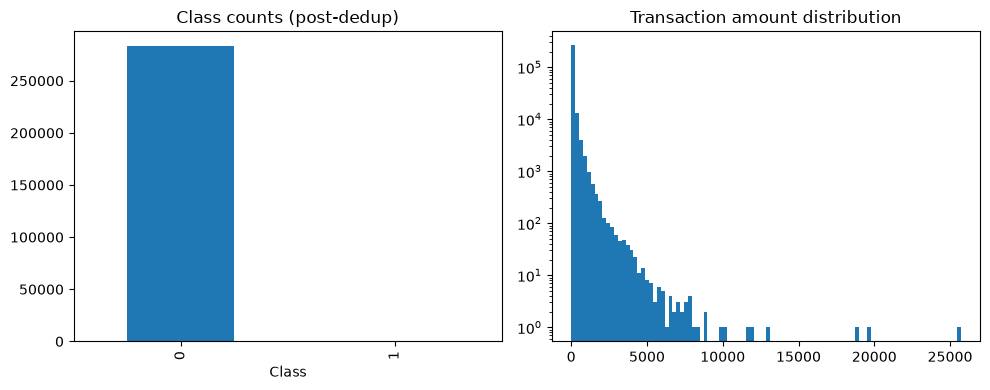

In [3]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df['Class'].value_counts().plot(kind='bar', ax=ax[0], title='Class counts (post-dedup)')
ax[1].hist(df['Amount'], bins=100)
ax[1].set_title('Transaction amount distribution')
ax[1].set_yscale('log')
plt.tight_layout()
plt.savefig('figures/eda_class_and_amount.png', dpi=150)
plt.show()


## 4. Baseline: majority-class predictor

In [4]:
from sklearn.metrics import (classification_report, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_curve)

y_all = df['Class']
majority_pred = np.zeros(len(y_all))
print(classification_report(y_all, majority_pred, digits=4, zero_division=0))
print(f"Macro F1: {f1_score(y_all, majority_pred, average='macro', zero_division=0):.4f}")


              precision    recall  f1-score   support

           0     0.9983    1.0000    0.9992    283253
           1     0.0000    0.0000    0.0000       473

    accuracy                         0.9983    283726
   macro avg     0.4992    0.5000    0.4996    283726
weighted avg     0.9967    0.9983    0.9975    283726

Macro F1: 0.4996


Accuracy looks like ~99.8% here despite the model doing nothing useful, since fraud is
~0.17% of transactions. This is why macro-F1 and AUC-PR (precision-recall AUC) -- not accuracy --
are the metrics used going forward.

**Why AUC-PR over AUC-ROC as the primary model-selection metric:** with such a skewed class
balance, ROC-AUC's false-positive-rate denominator is dominated by the huge negative class, making
it look deceptively good even for a mediocre model. AUC-PR is sensitive to how well the model finds
the rare positive class, which is the actual thing that matters operationally here.


## 5. Train / validation / test split

In [5]:
feature_cols = [c for c in df.columns if c != 'Class']
X = df[feature_cols].values
y = df['Class'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print(f"Train fraud rate: {y_train.mean():.5f}  Val: {y_val.mean():.5f}  Test: {y_test.mean():.5f}")


Train: 198608  Val: 42559  Test: 42559
Train fraud rate: 0.00167  Val: 0.00167  Test: 0.00167


In [6]:
# Scaled versions, for Logistic Regression only. Tree models use the unscaled X_train/X_val/X_test.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


## 6. Candidate models

Why weighting instead of SMOTE/oversampling: `class_weight="balanced"` / `scale_pos_weight`
reweight the existing real examples rather than synthesizing new fraud examples in a feature
space we have no real-world intuition for (the `V1`-`V28` features are anonymized PCA components,
so a synthetic point generated by SMOTE isn't interpretable as "a plausible transaction" the way it
might be with real, named features).


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

candidates = {
    "logistic_regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=SEED
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=SEED, n_jobs=-1
    ),
    "xgboost": xgb.XGBClassifier(
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=SEED, eval_metric="aucpr"
    ),
}

# Which split each model trains/evaluates on (scaled for LR, raw for tree models)
uses_scaled = {"logistic_regression": True, "random_forest": False, "xgboost": False}


## 7. Train and evaluate each candidate on validation

In [8]:
def evaluate(model, X, y, name, split_label=""):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    f1 = f1_score(y, pred, average="macro", zero_division=0)
    auc_roc = roc_auc_score(y, proba)
    auc_pr = average_precision_score(y, proba)
    print(f"[{split_label}] {name:20s} macro_f1={f1:.4f}  AUC-ROC={auc_roc:.4f}  AUC-PR={auc_pr:.4f}")
    return {"name": name, "model": model, "proba": proba, "pred": pred,
            "macro_f1": f1, "auc_roc": auc_roc, "auc_pr": auc_pr}

results = []
for name, model in candidates.items():
    Xtr = X_train_scaled if uses_scaled[name] else X_train
    Xv = X_val_scaled if uses_scaled[name] else X_val
    model.fit(Xtr, y_train)
    r = evaluate(model, Xv, y_val, name, split_label="VAL")
    results.append(r)


[VAL] logistic_regression  macro_f1=0.5409  AUC-ROC=0.9719  AUC-PR=0.6971
[VAL] random_forest        macro_f1=0.9159  AUC-ROC=0.9542  AUC-PR=0.8528
[VAL] xgboost              macro_f1=0.9218  AUC-ROC=0.9690  AUC-PR=0.8223


## 8. Select best model and tune the decision threshold -- on validation, not test

**Important methodological point:** the threshold is tuned here using validation-set predictions
only. The test set is touched exactly once, afterward, with this fixed threshold already decided --
otherwise, searching for the best threshold directly on the test set would itself be a form of
overfitting to the test set, even though no model parameters are being changed.

Cost assumptions below are illustrative placeholders (a bank would use real chargeback-loss and
false-decline-friction figures) -- what matters more than the exact dollar values is that the
chosen threshold is checked for being reasonably stable across a plausible range of cost ratios,
not just optimal for one specific pair of numbers.


Selected model (by validation AUC-PR): random_forest  (val AUC-PR=0.8528)
 threshold  false_negatives  false_positives  total_cost
      0.05                9               87        1335
      0.10               12               21        1305
      0.15               12                9        1245
      0.20               14                7        1435
      0.25               14                5        1425
      0.30               17                3        1715
      0.35               18                2        1810
      0.40               18                2        1810
      0.45               19                2        1910
      0.50               19                2        1910
      0.55               21                1        2105
      0.60               21                0        2100
      0.65               23                0        2300
      0.70               23                0        2300
      0.75               24                0        2400
      0.80    

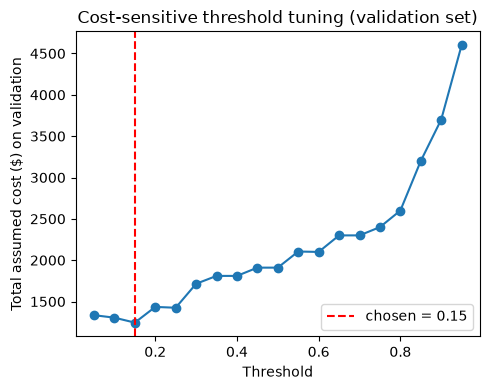

In [9]:
best = max(results, key=lambda r: r["auc_pr"])
print(f"Selected model (by validation AUC-PR): {best['name']}  (val AUC-PR={best['auc_pr']:.4f})")

best_uses_scaled = uses_scaled[best["name"]]
Xv_best = X_val_scaled if best_uses_scaled else X_val
val_proba = best["model"].predict_proba(Xv_best)[:, 1]

COST_FALSE_NEGATIVE = 100   # placeholder: assumed average loss per missed fraud ($)
COST_FALSE_POSITIVE = 5     # placeholder: assumed cost of a false alarm (customer friction/support)

thresholds = np.arange(0.05, 0.96, 0.05)
rows = []
for t in thresholds:
    pred = (val_proba >= t).astype(int)
    fn = ((pred == 0) & (y_val == 1)).sum()
    fp = ((pred == 1) & (y_val == 0)).sum()
    cost = fn * COST_FALSE_NEGATIVE + fp * COST_FALSE_POSITIVE
    rows.append({"threshold": round(t, 2), "false_negatives": fn, "false_positives": fp, "total_cost": cost})

cost_df = pd.DataFrame(rows)
print(cost_df.to_string(index=False))

chosen_threshold = cost_df.loc[cost_df["total_cost"].idxmin(), "threshold"]
print(f"\nChosen threshold (lowest cost on VALIDATION): {chosen_threshold:.2f}")

plt.figure(figsize=(5, 4))
plt.plot(cost_df["threshold"], cost_df["total_cost"], marker="o")
plt.axvline(chosen_threshold, color="red", linestyle="--", label=f"chosen = {chosen_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Total assumed cost ($) on validation")
plt.title("Cost-sensitive threshold tuning (validation set)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/cost_threshold_tuning.png", dpi=150)
plt.show()


### Sensitivity check: is the chosen threshold robust to the exact cost ratio?

Rather than trusting one specific ($100, $5) pair, check whether a nearby cost ratio would have
picked a meaningfully different threshold.


In [10]:
for fn_cost, fp_cost in [(50, 5), (100, 5), (200, 5), (100, 10)]:
    best_t, best_cost = None, None
    for t in thresholds:
        pred = (val_proba >= t).astype(int)
        fn = ((pred == 0) & (y_val == 1)).sum()
        fp = ((pred == 1) & (y_val == 0)).sum()
        c = fn * fn_cost + fp * fp_cost
        if best_cost is None or c < best_cost:
            best_cost, best_t = c, t
    print(f"FN cost={fn_cost:>4} FP cost={fp_cost:>3}  ->  best threshold={best_t:.2f}")


FN cost=  50 FP cost=  5  ->  best threshold=0.15
FN cost= 100 FP cost=  5  ->  best threshold=0.15
FN cost= 200 FP cost=  5  ->  best threshold=0.05
FN cost= 100 FP cost= 10  ->  best threshold=0.15


## 9. Final test-set evaluation (touched once)

Now, and only now, apply the model and the threshold chosen above to the held-out test set.


In [11]:
Xt_best = X_test_scaled if best_uses_scaled else X_test
test_proba = best["model"].predict_proba(Xt_best)[:, 1]
test_pred = (test_proba >= chosen_threshold).astype(int)

print(f"FINAL TEST -- {best['name']}  threshold={chosen_threshold:.2f}")
print(classification_report(y_test, test_pred, digits=4, zero_division=0))
print(f"AUC-ROC: {roc_auc_score(y_test, test_proba):.4f}   AUC-PR: {average_precision_score(y_test, test_proba):.4f}")


FINAL TEST -- random_forest  threshold=0.15
              precision    recall  f1-score   support

           0     0.9997    0.9996    0.9996     42488
           1     0.7733    0.8169    0.7945        71

    accuracy                         0.9993     42559
   macro avg     0.8865    0.9083    0.8971     42559
weighted avg     0.9993    0.9993    0.9993     42559

AUC-ROC: 0.9606   AUC-PR: 0.8034


### Confusion matrix and precision-recall curve

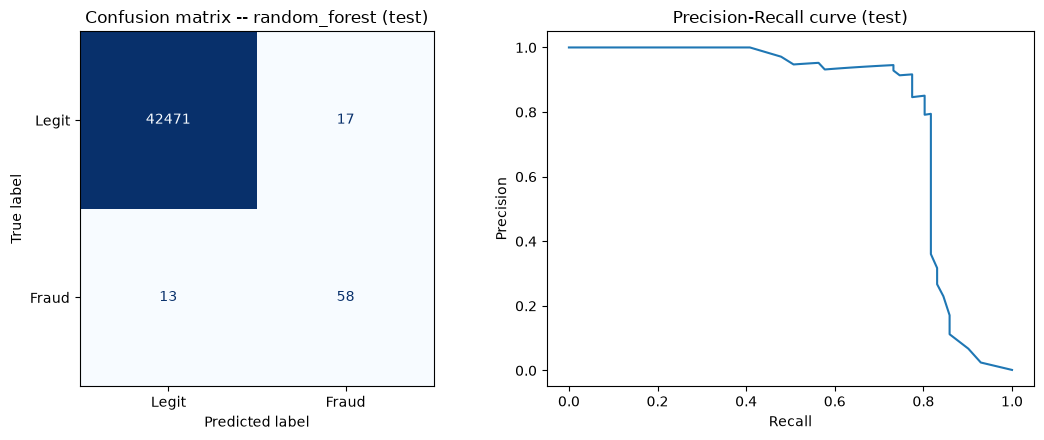

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion matrix -- {best['name']} (test)")

precision, recall, _ = precision_recall_curve(y_test, test_proba)
axes[1].plot(recall, precision)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve (test)")

plt.tight_layout()
plt.savefig(f"figures/confusion_matrix_and_pr_curve_{best['name']}.png", dpi=150)
plt.show()


## 10. Model calibration check

The cost-sensitive threshold logic in Section 8 implicitly assumes `predict_proba` outputs mean
something like "true probability of fraud." Tree ensembles in particular are not always
well-calibrated out of the box, so this is worth checking rather than assuming.


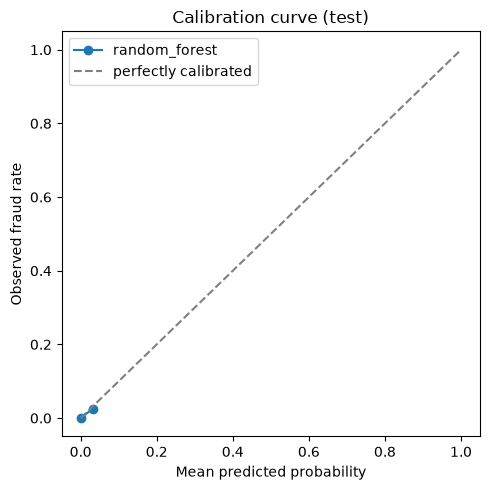

In [13]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=10, strategy="quantile")

plt.figure(figsize=(5, 5))
plt.plot(prob_pred, prob_true, marker="o", label=best["name"])
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraud rate")
plt.title("Calibration curve (test)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/calibration_curve.png", dpi=150)
plt.show()


## 11. Error analysis

Not just confusion-matrix counts -- look at what actually characterizes the transactions the
model got wrong.


In [14]:
fn_mask = (test_pred == 0) & (y_test == 1)
fp_mask = (test_pred == 1) & (y_test == 0)
tp_mask = (test_pred == 1) & (y_test == 1)

print(f"False negatives (missed fraud): {fn_mask.sum()}")
print(f"False positives (false alarms): {fp_mask.sum()}")
print(f"True positives (caught fraud):  {tp_mask.sum()}")

amount_col_idx = feature_cols.index("Amount")
test_amounts = X_test[:, amount_col_idx]

print("\nAmount summary by group:")
for label, mask in [("False negatives", fn_mask), ("False positives", fp_mask), ("True positives", tp_mask)]:
    if mask.sum() > 0:
        vals = test_amounts[mask]
        print(f"  {label:18s} n={mask.sum():3d}  mean=${vals.mean():8.2f}  median=${np.median(vals):8.2f}")


False negatives (missed fraud): 13
False positives (false alarms): 17
True positives (caught fraud):  58

Amount summary by group:
  False negatives    n= 13  mean=$  248.30  median=$   29.95
  False positives    n= 17  mean=$  118.51  median=$   19.95
  True positives     n= 58  mean=$  103.67  median=$   11.50


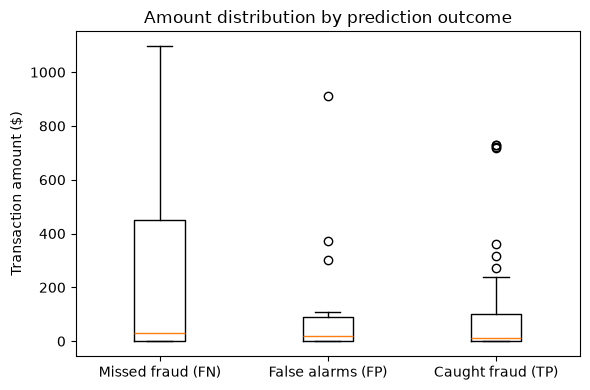

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
groups = [("Missed fraud (FN)", test_amounts[fn_mask]),
          ("False alarms (FP)", test_amounts[fp_mask]),
          ("Caught fraud (TP)", test_amounts[tp_mask])]
ax.boxplot([g[1] for g in groups if len(g[1]) > 0],
           tick_labels=[g[0] for g in groups if len(g[1]) > 0])
ax.set_ylabel("Transaction amount ($)")
ax.set_title("Amount distribution by prediction outcome")
plt.tight_layout()
plt.savefig("figures/error_analysis_amount_by_outcome.png", dpi=150)
plt.show()


## 12. Explainability (SHAP)

Finance models get scrutinized for interpretability -- especially anything touching credit
decisions (Fair Lending laws). Even for fraud, being able to explain *why* a transaction was
flagged matters operationally (a fraud analyst needs a reason, not just a score).


/tmp/ipykernel_17757/1675458095.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_input, feature_names=feature_cols, show=False)
/home/jay/fraud_detection_project/.venv/lib/python3.14/site-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/home/jay/fraud_detection_project/.venv/lib/python3.14/site-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence th

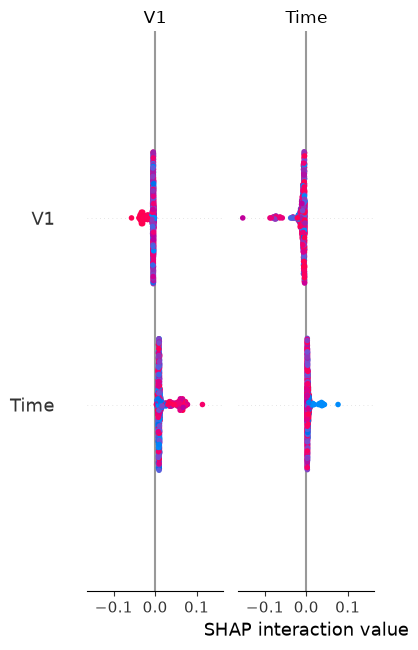

In [17]:
import shap

if hasattr(best["model"], "feature_importances_"):
    explainer = shap.TreeExplainer(best["model"])
else:
    explainer = shap.LinearExplainer(best["model"], X_train_scaled)

X_shap_input = X_test_scaled[:500] if best_uses_scaled else X_test[:500]
shap_values = explainer.shap_values(X_shap_input)

shap.summary_plot(shap_values, X_shap_input, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.savefig("figures/shap_summary.png", dpi=150)
plt.show()


## 13. Confidence-based routing to manual review

Quantify what fraction of transactions could be auto-decided at high confidence vs. routed to a
human analyst, and how much reliability improves on the auto-decided subset.


In [18]:
confidence = np.abs(test_proba - 0.5) * 2  # distance from decision boundary, rescaled to [0,1]

conf_thresholds = [0.0, 0.5, 0.7, 0.8, 0.9]
rows = []
for t in conf_thresholds:
    keep = confidence >= t
    coverage = keep.mean()
    f1_kept = f1_score(y_test[keep], test_pred[keep], average="macro", zero_division=0) if keep.sum() else float("nan")
    rows.append({"confidence_threshold": t, "coverage": coverage, "macro_f1_on_kept": f1_kept})

print(pd.DataFrame(rows).to_string(index=False))


 confidence_threshold  coverage  macro_f1_on_kept
                  0.0  1.000000          0.897084
                  0.5  0.999718          0.910717
                  0.7  0.999436          0.923323
                  0.8  0.999084          0.919906
                  0.9  0.997815          0.914552


## 14. Conclusion and next steps

TODO after running the full notebook with real numbers:
- State which model won and why (val AUC-PR), and confirm it's still the best after the dedup fix.
- State final test performance (macro-F1, AUC-ROC, AUC-PR) and the chosen, validation-derived threshold.
- Note whether the threshold sensitivity check (Section 8) showed a stable or fragile threshold choice.
- State the calibration curve's shape -- is the model over- or under-confident?
- Summarize the dominant error pattern from Section 11 (does missed fraud cluster by amount?).
- Note the top SHAP features driving fraud predictions.
- State the confidence/coverage trade-off from Section 13.

Known limitations:
- Random split used instead of time-based, given the dataset's short (~2 day) time span; a
  production model would need longer-horizon validation to catch concept drift.
- Cost assumptions ($100 FN / $5 FP) are illustrative, not sourced from real chargeback/friction data.
- Test set has very few positive examples (double check exact count after dedup), so point-estimate
  metrics carry meaningful uncertainty; consider bootstrapped confidence intervals with more time.
- No hyperparameter tuning beyond class-weighting; a tuned XGBoost via RandomizedSearchCV would
  likely improve on these numbers further.

Next experiments (priority order):
1. Bootstrapped confidence intervals on test metrics, given the small positive-class test size.
2. Light hyperparameter search (RandomizedSearchCV) on the winning model.
3. SMOTE/other resampling as a comparison point against class weighting, now that a clean
   baseline exists.
4. If more data with real timestamps spanning weeks/months were available, a genuine time-based
   split and drift analysis.
